Notebook 3: Tomographyic-like approach
===============================================================================

In [8]:
# importazione di librerie e moduli
import sys
import copy
import numpy as np
import pickle

sys.path.insert(1, '../swa')

from utils import *
from _stream import SeismicStream
from _curve import Curve

import matplotlib
import matplotlib.pyplot as plt
matplotlib.use('Qt5Agg')

In [9]:
# set dei percorsi
version = 'v1'
prj_dir = '../data/syn_data'

path2raw = os.path.join(prj_dir,'raw')
path2geom = f'{prj_dir}/geometry_test.csv'
path2fk = f'{prj_dir}/proc/{version}/fk_filter'
path2diffs = f"{prj_dir}/proc/{version}/tomo2d/phase_diffs"
path2plot = f'{prj_dir}/proc/{version}/plots/'
path2dc = f"{prj_dir}/proc/{version}/tomo2d/dc"
ext = '.sgy' # shot file extension

# List of directories to create
directories = [path2raw, path2geom, path2fk, path2diffs, path2dc, path2plot]
def create_dir(dir_list):
    for directory in dir_list:
        if not os.path.exists(directory):
            os.makedirs(directory)
            print(f"📁 Directory created: {directory}")
create_dir(directories)

In [10]:
# dizionario con le impostazioni di processing e plot
settings = create_settings_dict(
                         fmin=7, fmax=50,                  # frequency range
                         vmin=20, vmax=1000, velstep=1)     # testing phase velocity range and step

# apply FK filtering
filter_fk = True

# get paths to shot files
path2sht = [f.path for f in os.scandir(path2raw) if f.is_file()]
path2sht = natural_sort(path2sht)
path2sht = [[f] for f in path2sht]

# define offset range (which kind of offset do we talk?)
min_offset = 1
max_offset = 1e4

# minimum receiver number
min_nrec = 2

## 1. FK filtering + calcolo delle differenze di fase
se non già effettuato, qui avviene il picking in f-k per rimuovere i modi superiori. In modo iterativo ed automatico per ciascuno shot poi, vengono calcolate le differenze di fase tra ricevitori adiacenti, per ogni frequenza. Queste sono salvate in un unico file <code>all_phase_diffs.pickle

In [11]:
# %% phase differences
all_phase_diffs = []

for i in range(0,len(path2sht)):

    # read seismic data
    stream = SeismicStream(path2sht[i][0], settings) # record
    fids = stream._argfreq()                         # indices of frequency subset
    nrec = len(stream.receiver)

    # create copy of stream object
    stream_fw = copy.deepcopy(stream) # copy
    stream_rw = copy.deepcopy(stream)  # copy

    fn = os.path.splitext(os.path.basename(path2sht[i][0]))[0] # filename

    # %% process forward shots
    phase_diffs = np.empty((len(fids), nrec - 1))
    phase_diffs[:] = np.nan

    # define offset range
    offset = stream.receiver[:-1] - stream.source  # signed offset vector
    oids = np.argwhere((offset >= min_offset) & (offset <= max_offset))[:, 0]

    if len(offset[oids]) >= min_nrec:

        # filter by offset (remove near offsets)
        stream_fw._select_traces(oids)

        # apply fk filtering to remove higher modes
        fk_fname = f'{path2fk}/fw_shots/fkfilter_{fn}.txt'
        path, _ = os.path.split(fk_fname)
        safe_makedirs(path)

        if filter_fk:
            # if file exits apply fk filter
            if os.path.isfile(fk_fname):
                stream_fw._fk_filter_from_file(fname=fk_fname,
                                            show=False)
            # otherwise pick in data
            else:
                stream_fw._fk_filter_from_pick(fname=fk_fname,
                                            show=False)

        # compute phase differences
        phase_diffs_sub, fids = stream_fw._compute_phasediffs()

        # store in array
        phase_diffs[:,oids[:-1]] = phase_diffs_sub

    # %% process reverse shots
    oids = np.argwhere((offset >= -max_offset) & (offset <= -min_offset))[:, 0]

    if len(offset[oids]) >= min_nrec:
        # filter by offset (remove near offsets)
        stream_rw._select_traces(oids)

        # apply fk filtering to remove higher modes
        fk_fname = f'{path2fk}/rw_shots/fkfilter_{fn}.txt'
        path, _ = os.path.split(fk_fname)
        safe_makedirs(path)

        # if file exits apply fk filter+
        if filter_fk:
            if os.path.isfile(fk_fname):
                stream_rw._fk_filter_from_file(fname=fk_fname,
                                               show=False)
            # otherwise pick in data
            else:
                stream_rw._fk_filter_from_pick(fname=fk_fname,
                                               show=False)

        # compute phase differences
        phase_diffs_sub, fids = stream_rw._compute_phasediffs()

        # store in array
        phase_diffs[:,oids[:-1]] = phase_diffs_sub

    all_phase_diffs.append(phase_diffs)

# %% save all phase differences
safe_makedirs(path2diffs)
with open(f"{path2diffs}/all_phase_diffs.pickle", "wb") as fp:
    pickle.dump(all_phase_diffs, fp)

## 2. Inversione tomografica
qui si recupera il file <code>all_phase_diffs.pickle</code>, si definiscono i parametri di regolarizzazione ed errore per l'inversione e si esegue il processo

In [12]:
# file containing all phase differences per shots
with open(f"{path2diffs}/all_phase_diffs.pickle", "rb") as fp:
    all_phase_diffs = pickle.load(fp)

# define offset range
min_offset = 10
max_offset = 20

# regularization parameter
lam = 200
rel_err = 12/100

# recording parameters
rec0 = SeismicStream(path2sht[0][0], settings)      # record0
nshots = len(path2sht)                              # number of shots
nrec = len(rec0.receiver)                           # number of receivers
dx = np.mean(np.diff(rec0.receiver))                # receiver separataion
dt = rec0.dt                                        # sampling rate in s
npts = rec0.npts                                    # number of samples
fids = rec0._argfreq()

# frequency range
freq = recordParam2freq(dt,npts)
freq_sel = freq[fids]

# allocate space
phi_vel_all = np.zeros((nrec-1,len(freq_sel)))

for jj,f in enumerate(freq_sel):

    A = np.zeros((2*nshots*nrec-1,nrec-1)) # design matrix
    dphi = np.zeros((2*nshots*nrec-1,1)) # phase vector
    error = np.zeros((2*nshots*nrec-1,1)) # error vector
    iii = 0

    for kk in range(0, len(path2sht)):

        stream = SeismicStream(path2sht[kk][0], settings)

        # %% process forward shots
        # define offset range
        offset = stream.receiver[:-1] - stream.source  # signed offset vector
        oids = np.argwhere((offset >= min_offset) & (offset <= max_offset))[:, 0]

        # fill A and dphi
        for ii in oids:
            if all_phase_diffs[kk][jj,ii]<0:
                iii += 1
                A[iii,ii] = dx
                dphi[iii] = all_phase_diffs[kk][jj,ii]
                abs_err = rel_err * all_phase_diffs[kk][jj,ii]
                error[iii] = abs_err

        # %% process reverse shots
        #define offset range
        oids = np.argwhere((offset >= -max_offset) & (offset <= -min_offset))[:, 0]

        # fill A and dphi
        for ii in oids:
            if all_phase_diffs[kk][jj,ii]>0:
                iii += 1
                A[iii,ii] = -dx
                dphi[iii] = all_phase_diffs[kk][jj,ii]
                abs_err = rel_err * all_phase_diffs[kk][jj,ii]
                error[iii] = abs_err

    # solve equations
    #weights /= np.var(error)
    A = A[~np.all(A == 0, axis=1)]
    dphi = dphi[~np.all(dphi == 0, axis=1)].reshape((-1,))
    error = error[~np.all(error == 0, axis=1)].reshape((-1,))

    weights = 1/error**2
    w = np.diag(weights)
    phi_vel, phi_model = tomo2D_phasediff(lam=lam, f=f, A=A, dphi=dphi, w=w)
    phi_vel_all[:,jj] = phi_vel

# save dispersion curves
for i in range(len(phi_vel_all)):
    dc = Curve()
    dc._init_data(freq_sel, phi_vel_all[i,:], err = None)
    dc._save(path2dc, f'dc{i}', format = 'csv')


## Plot

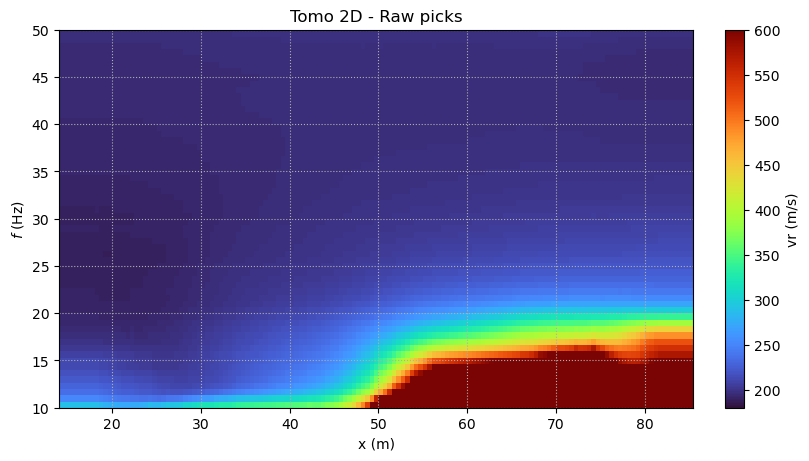

In [13]:
%matplotlib inline

# %% plot result
vmin = 180
vmax = 600
xmids = rec0.receiver[:-1] + dx/2

fig,ax = plt.subplots(figsize=(8, 4.5), constrained_layout = True)
for i in range(len(phi_vel_all)):
    curve = Curve()
    curve._init_data(freq_sel, phi_vel_all[i,:], err = None)

    curve._plotColumn(axes = ax,
                  xmid = xmids[i],
                  vmin = vmin, vmax = vmax,
                  cmap = 'turbo', y_value = 'f',
                  width = 0.5)

plot_colorBar(ax, vmin, vmax, cmap='turbo', orientation='vertical')
ax.set_xlim([rec0.receiver[0],rec0.receiver[-1]])
ax.set_ylim([10,50])

ax.set_title('Tomo 2D - Raw picks')
fig.savefig(os.path.join(path2plot,'3_tomo2D.png'), dpi=200)
#fig.savefig('figures/3_tomo2D.png', dpi=200)
plt.show()